# Klasifikasi Huruf dan Angka Bahasa Isyarat (ASL) Menggunakan Convolutional Neural Network (CNN) dengan Transfer Learning MobileNetV2

---

## Dataset

Tugas ini menggunakan **dua dataset publik** yang digabungkan:

1. **Sign Language MNIST** (sumber: Kaggle — datamunge)  
   Berisi citra tangan untuk huruf A–Z (24 kelas, tanpa J dan Z). Format CSV dengan ukuran citra 28×28 piksel dalam skala keabuan.

2. **Sign Language Digits Dataset** (sumber: Kaggle — ardamavi)  
   Berisi citra tangan untuk angka 0–9 (10 kelas). Format NumPy array (.npy) dengan ukuran citra 64×64 piksel dalam skala keabuan.

Kedua dataset digabungkan setelah diseragamkan ukurannya, sehingga menghasilkan satu dataset terpadu untuk proses pelatihan dan pengujian model.

## Metode

Model yang digunakan adalah **Convolutional Neural Network (CNN)** dengan pendekatan **Transfer Learning** menggunakan arsitektur **MobileNetV2**. MobileNetV2 dipilih karena arsitekturnya yang ringan dan efisien, namun tetap memiliki performa tinggi, sehingga cocok untuk eksperimen di lingkungan Google Colab dengan sumber daya terbatas.

## Alur Proses

Secara umum, alur proses dalam tugas ini adalah sebagai berikut:

```
[Load Dataset 1: Sign MNIST]  +  [Load Dataset 2: Digits .npy]
                    ↓
           Resize & Normalisasi
                    ↓
       Exploratory Data Analysis (EDA)
                    ↓
    Split Train / Validation / Test
                    ↓
         Augmentasi Data Training
                    ↓
   Transfer Learning: MobileNetV2 + Head Baru
                    ↓
        Training (Frozen → Fine-Tuning)
                    ↓
      Evaluasi: Akurasi, F1, Confusion Matrix
                    ↓
       Analisis Kesalahan Klasifikasi
```

---
# 1. Persiapan Lingkungan

## 1.1 Import Library

Berikut adalah library yang digunakan dalam tugas ini:
- **NumPy & Pandas** — manipulasi data dan array
- **Matplotlib & Seaborn** — visualisasi data
- **Scikit-learn** — evaluasi model dan pembagian data
- **TensorFlow / Keras** — membangun dan melatih model CNN

In [ ]:
%pip install tensorflow scikit-learn pandas numpy matplotlib seaborn opencv-python

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

print('TensorFlow version:', tf.__version__)
print('GPU tersedia:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU tersedia: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
# 2. Load dan Penggabungan Dataset

## 2.1 Load Dataset 1 — Sign Language MNIST (Huruf A–Z)

Dataset Sign Language MNIST tersimpan dalam format CSV. Kolom pertama berisi label (0–25 untuk A–Z), dan kolom sisanya berisi nilai 784 piksel (28×28). Karena huruf **J** (label 9) dan **Z** (label 25) memerlukan gesture bergerak, kedua kelas ini dihapus dari dataset, sehingga tersisa **24 kelas huruf**.

In [ ]:
# Load data huruf
DRIVE_PATH = 'data/' 
train_letters = pd.read_csv(DRIVE_PATH + 'sign_mnist_train.csv')
test_letters  = pd.read_csv(DRIVE_PATH + 'sign_mnist_test.csv')

df_letters = pd.concat([train_letters, test_letters], ignore_index=True)

# Hapus kelas J (9) dan Z (25)
df_letters = df_letters[~df_letters['label'].isin([9, 25])]

X_letters = df_letters.loc[:, 'pixel1':].values.astype(np.float32)
y_letters_raw = df_letters['label'].values

# Ubah label numerik ke nama huruf (A=0, B=1, ..., skip J & Z)
alphabet = [chr(ord('A') + i) for i in range(26) if i not in [9, 25]]  # 24 huruf
label_map_letters = {orig: letter for orig, letter in zip(sorted(df_letters['label'].unique()), alphabet)}
y_letters = np.array([label_map_letters[l] for l in y_letters_raw])

# Reshape ke (N, 28, 28)
X_letters = X_letters.reshape(-1, 28, 28)

print(f'Jumlah data huruf : {len(X_letters)}')
print(f'Kelas huruf       : {sorted(np.unique(y_letters))}')

Jumlah data huruf : 34627
Kelas huruf       : [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('K'), np.str_('L'), np.str_('M'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('R'), np.str_('S'), np.str_('T'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y')]


## 2.2 Load Dataset 2 — Sign Language Digits (Angka 0–9)

Dataset angka tersimpan dalam format NumPy array (.npy). `X.npy` berisi array citra dengan ukuran 64×64 piksel, dan `Y.npy` berisi label dalam format one-hot encoding yang kemudian dikonversi ke label integer.

In [5]:
# Load data angka
X_digits_raw = np.load(DRIVE_PATH + 'X.npy')  # shape: (N, 64, 64)
Y_digits_raw = np.load(DRIVE_PATH + 'Y.npy')  # one-hot encoded

# Konversi one-hot ke label integer, lalu ke string '0'-'9'
y_digits_int = np.argmax(Y_digits_raw, axis=1)
y_digits = np.array([str(d) for d in y_digits_int])

# Jika channel ada (N, 64, 64, 1), squeeze
if X_digits_raw.ndim == 4:
    X_digits_raw = X_digits_raw.squeeze(-1)

X_digits = X_digits_raw.astype(np.float32)

print(f'Jumlah data angka  : {len(X_digits)}')
print(f'Ukuran citra angka : {X_digits.shape[1:]}')
print(f'Kelas angka        : {sorted(np.unique(y_digits))}')

Jumlah data angka  : 2062
Ukuran citra angka : (64, 64)
Kelas angka        : [np.str_('0'), np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9')]


## 2.3 Resize dan Gabungkan Dataset

Kedua dataset memiliki ukuran citra yang berbeda (28×28 vs 64×64). Agar dapat digabungkan dan digunakan oleh MobileNetV2 (yang memerlukan input minimal 32×32, dan idealnya 96×96 ke atas), semua citra di-resize menjadi **64×64 piksel**. Kemudian citra diubah menjadi 3 channel (RGB) karena MobileNetV2 dilatih dengan citra berwarna.

In [6]:
import cv2

IMG_SIZE = 64  # ukuran target

def resize_images(images, size):
    resized = []
    for img in images:
        r = cv2.resize(img, (size, size))
        resized.append(r)
    return np.array(resized)

def to_rgb(images):
    """Mengubah grayscale (H,W) -> RGB (H,W,3) dengan menduplikasi channel."""
    return np.stack([images, images, images], axis=-1)

# Resize huruf ke 64x64
X_letters_resized = resize_images(X_letters, IMG_SIZE)

# Ubah ke RGB
X_letters_rgb = to_rgb(X_letters_resized)   # (N, 64, 64, 3)
X_digits_rgb  = to_rgb(X_digits)            # (N, 64, 64, 3)

# Gabungkan
X_all = np.concatenate([X_letters_rgb, X_digits_rgb], axis=0)
y_all = np.concatenate([y_letters, y_digits], axis=0)

print(f'Total data gabungan : {len(X_all)}')
print(f'Shape X             : {X_all.shape}')
print(f'Total kelas         : {len(np.unique(y_all))} → {sorted(np.unique(y_all))}')

Total data gabungan : 36689
Shape X             : (36689, 64, 64, 3)
Total kelas         : 34 → [np.str_('0'), np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9'), np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('K'), np.str_('L'), np.str_('M'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('R'), np.str_('S'), np.str_('T'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y')]


---
# 3. Exploratory Data Analysis (EDA)

## 3.1 Distribusi Kelas

Sebelum melatih model, penting untuk memahami distribusi data di setiap kelas. Distribusi yang tidak seimbang (*class imbalance*) dapat menyebabkan model cenderung memihak kelas yang memiliki lebih banyak data.

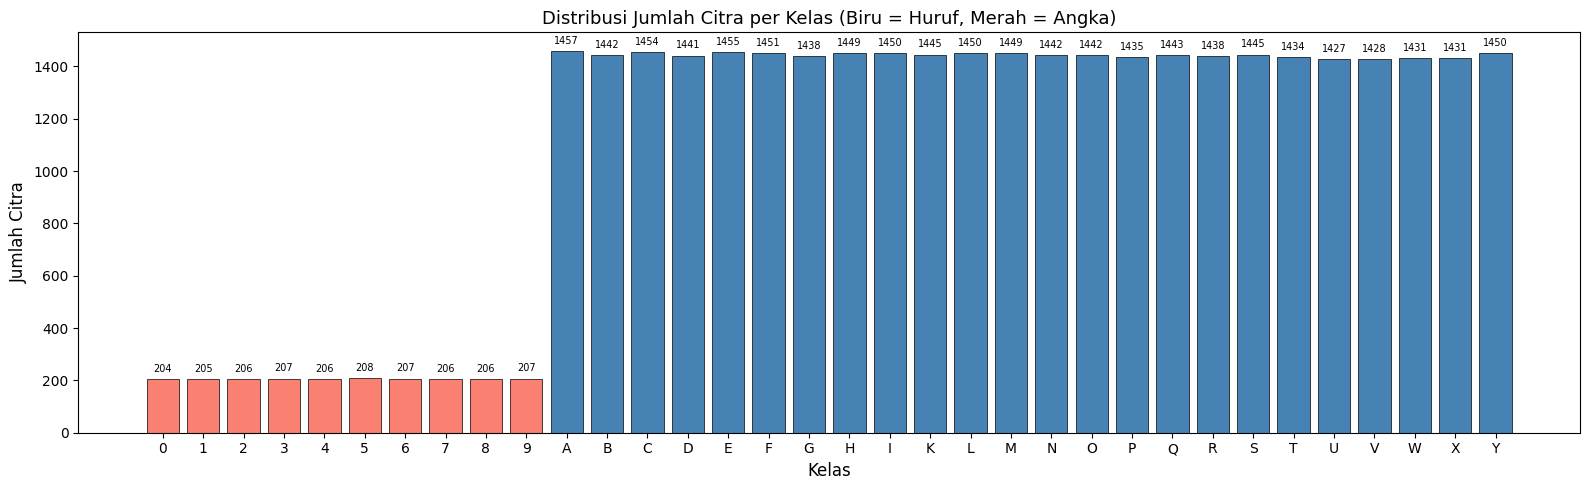


Min data per kelas : 204 (kelas: 0)
Max data per kelas : 1457 (kelas: A)
Rata-rata          : 1079


In [7]:
unique_classes, counts = np.unique(y_all, return_counts=True)

plt.figure(figsize=(16, 5))
colors = ['steelblue' if c.isalpha() else 'salmon' for c in unique_classes]
bars = plt.bar(unique_classes, counts, color=colors, edgecolor='black', linewidth=0.5)
plt.xlabel('Kelas', fontsize=12)
plt.ylabel('Jumlah Citra', fontsize=12)
plt.title('Distribusi Jumlah Citra per Kelas (Biru = Huruf, Merah = Angka)', fontsize=13)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(count), ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

print(f'\nMin data per kelas : {counts.min()} (kelas: {unique_classes[counts.argmin()]})')
print(f'Max data per kelas : {counts.max()} (kelas: {unique_classes[counts.argmax()]})')
print(f'Rata-rata          : {counts.mean():.0f}')

## 3.2 Visualisasi Contoh Citra

Berikut adalah contoh citra dari masing-masing kelas yang ada dalam dataset gabungan.

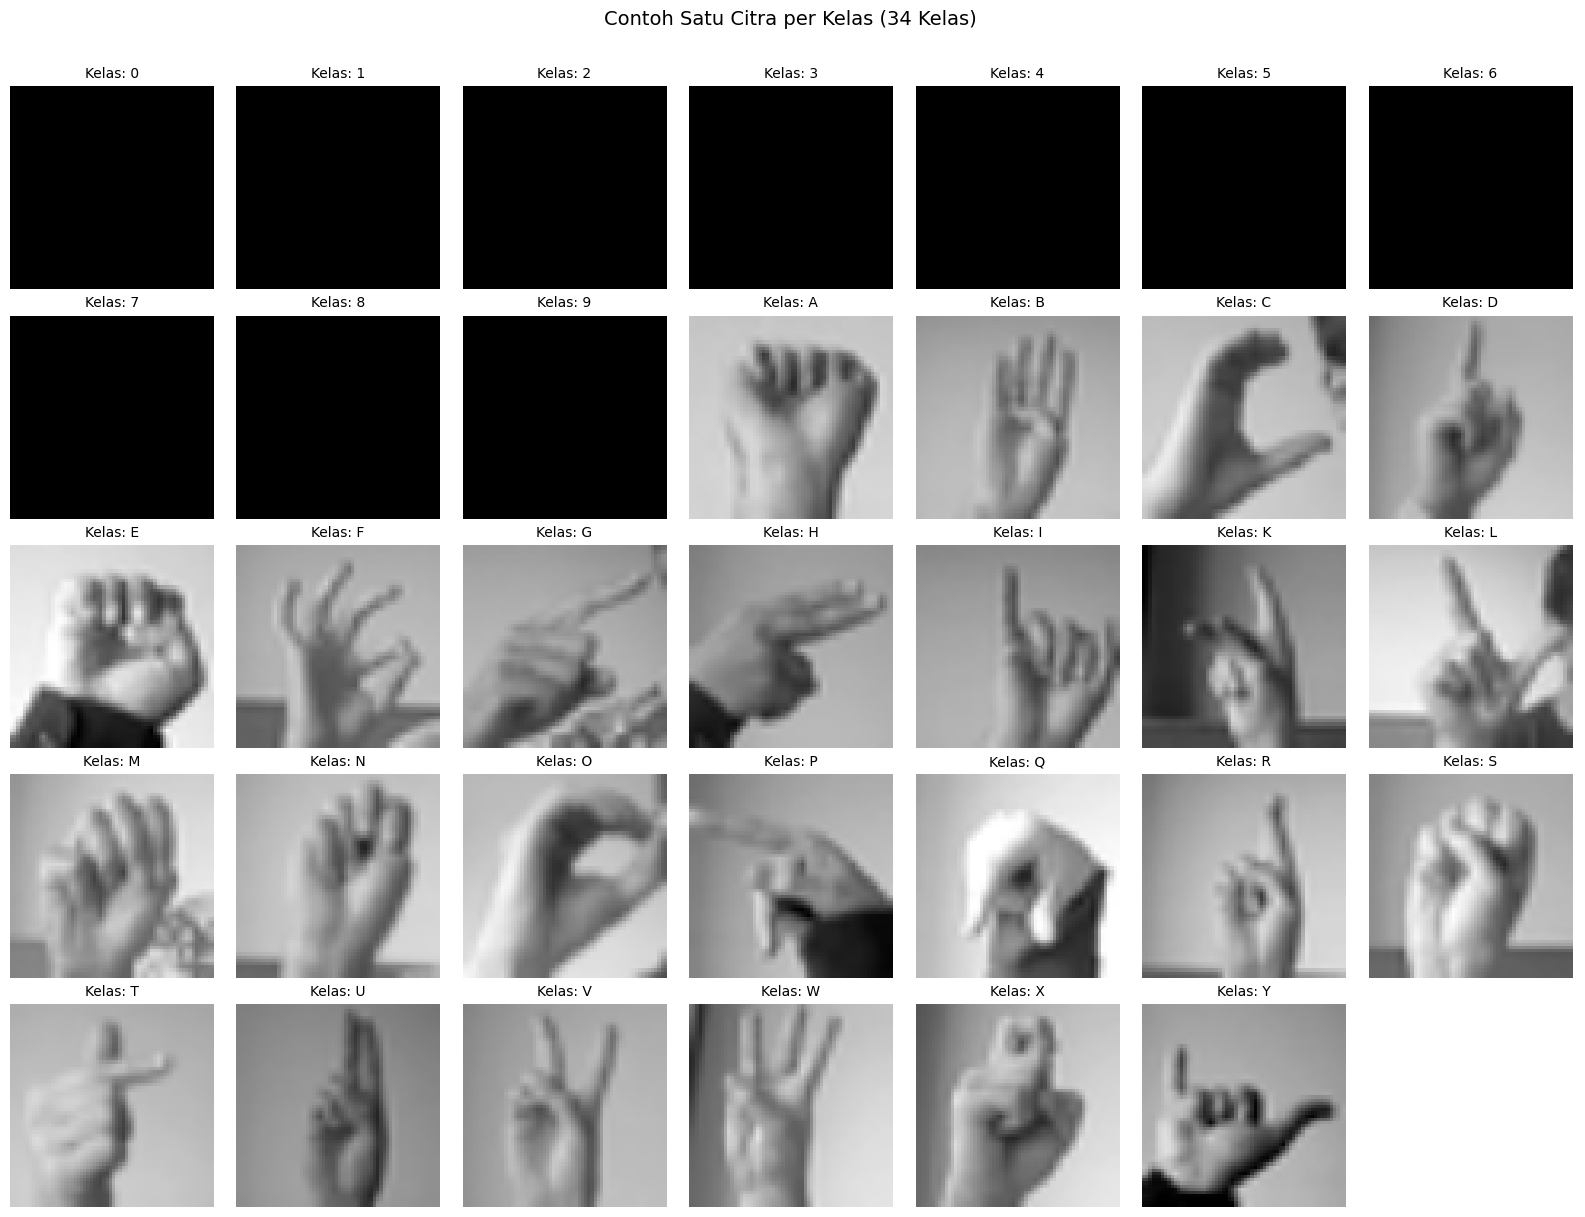

In [8]:
fig, axes = plt.subplots(5, 7, figsize=(16, 12))
axes = axes.flatten()

for i, cls in enumerate(sorted(unique_classes)):
    idx = np.where(y_all == cls)[0][0]
    axes[i].imshow(X_all[idx].astype(np.uint8), cmap='gray')
    axes[i].set_title(f'Kelas: {cls}', fontsize=10)
    axes[i].axis('off')

# Sembunyikan axes kosong
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Contoh Satu Citra per Kelas (34 Kelas)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
# 4. Praproses Data

## 4.1 Normalisasi

Nilai piksel citra dinormalisasi dari rentang **0–255** menjadi **0.0–1.0**. Normalisasi bertujuan untuk mempercepat konvergensi saat proses pelatihan dan menstabilkan gradien pada jaringan saraf.

In [9]:
X_norm = X_all / 255.0

print('Nilai piksel sebelum normalisasi:', X_all.min(), '–', X_all.max())
print('Nilai piksel setelah normalisasi :', X_norm.min(), '–', X_norm.max())

Nilai piksel sebelum normalisasi: 0.0 – 255.0
Nilai piksel setelah normalisasi : 0.0 – 1.0


## 4.2 Encoding Label

Label kelas berupa string (huruf dan angka) dikonversi ke format integer menggunakan `LabelEncoder`, kemudian diubah ke format **one-hot encoding** karena model CNN dengan output *softmax* memerlukan format ini.

In [10]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_all)   # string → integer
NUM_CLASSES = len(le.classes_)

y_onehot = to_categorical(y_encoded, num_classes=NUM_CLASSES)

print(f'Kelas (urutan)  : {le.classes_}')
print(f'Jumlah kelas    : {NUM_CLASSES}')
print(f'Shape y_onehot  : {y_onehot.shape}')

Kelas (urutan)  : ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H'
 'I' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y']
Jumlah kelas    : 34
Shape y_onehot  : (36689, 34)


## 4.3 Pembagian Data: Train / Validation / Test

Dataset dibagi menjadi tiga bagian:
- **Training (70%)** — digunakan untuk melatih model
- **Validation (15%)** — digunakan untuk memantau performa selama pelatihan dan mencegah *overfitting*
- **Testing (15%)** — digunakan untuk evaluasi akhir model

Pembagian dilakukan secara **stratified** agar distribusi kelas tetap seimbang di setiap subset.

In [11]:
# Split train vs (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_norm, y_onehot, test_size=0.30, random_state=42, stratify=y_encoded
)

# Split val vs test dari sisa 30%
y_temp_int = np.argmax(y_temp, axis=1)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp_int
)

print(f'Data Training   : {X_train.shape[0]} citra')
print(f'Data Validasi   : {X_val.shape[0]} citra')
print(f'Data Testing    : {X_test.shape[0]} citra')

Data Training   : 25682 citra
Data Validasi   : 5503 citra
Data Testing    : 5504 citra


## 4.4 Augmentasi Data Training

Dilakukan teknik augmentasi untuk memperbanyak variasi data training secara buatan tanpa mengumpulkan data baru. Teknik ini membantu model menjadi lebih **robust** dan mengurangi *overfitting*. Augmentasi yang diterapkan antara lain:

| Teknik | Deskripsi |
|---|---|
| `rotation_range=10` | Rotasi acak hingga ±10 derajat |
| `width_shift_range=0.1` | Pergeseran horizontal ±10% |
| `height_shift_range=0.1` | Pergeseran vertikal ±10% |
| `zoom_range=0.1` | Zoom acak ±10% |
| `horizontal_flip=False` | Tidak di-flip (penting: tangan kiri ≠ kanan) |

> **Catatan:** `horizontal_flip` dinonaktifkan karena dalam bahasa isyarat, orientasi kiri–kanan tangan memiliki makna yang berbeda.

In [12]:
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False
)

val_datagen = ImageDataGenerator()  # tidak ada augmentasi untuk validasi

BATCH_SIZE = 64

train_gen = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=42)
val_gen   = val_datagen.flow(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

print(f'Batch size       : {BATCH_SIZE}')
print(f'Jumlah batch/epoch: {len(train_gen)}')

Batch size       : 64
Jumlah batch/epoch: 402


### Visualisasi Hasil Augmentasi

Berikut adalah contoh hasil augmentasi pada beberapa citra training.

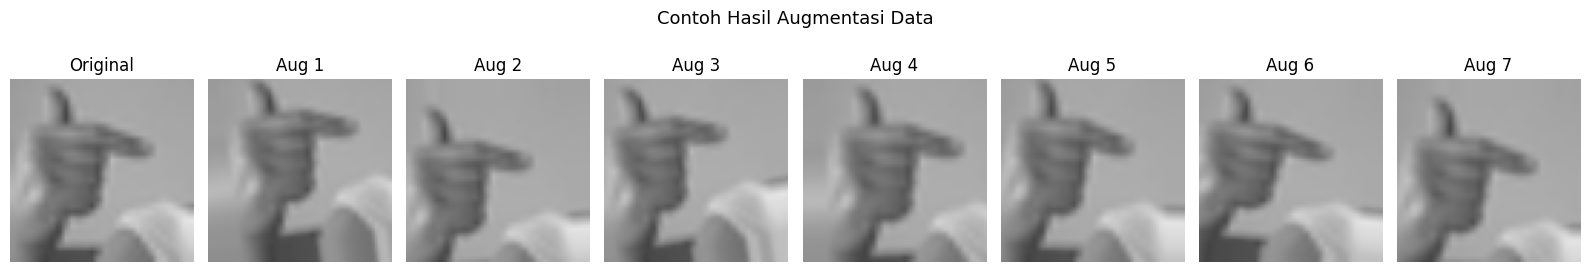

In [13]:
sample_img = X_train[:1]  # ambil 1 citra
aug_gen = train_datagen.flow(sample_img, batch_size=1)

fig, axes = plt.subplots(1, 8, figsize=(16, 3))
axes[0].imshow(sample_img[0], cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
for i in range(1, 8):
    aug_img = next(aug_gen)[0]
    axes[i].imshow(aug_img, cmap='gray')
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')
plt.suptitle('Contoh Hasil Augmentasi Data', fontsize=13)
plt.tight_layout()
plt.show()

---
# 5. Membangun Model CNN dengan Transfer Learning MobileNetV2

## Penjelasan Arsitektur

**Convolutional Neural Network (CNN)** adalah jenis jaringan saraf tiruan yang dirancang khusus untuk memproses data berbentuk grid seperti citra. CNN bekerja dengan menggunakan lapisan *convolutional* yang mengekstrak fitur spasial dari citra secara hierarkis — mulai dari fitur sederhana (tepi, sudut) hingga fitur kompleks (bentuk tangan secara keseluruhan).

**Transfer Learning** adalah pendekatan di mana model yang sudah dilatih pada dataset besar (dalam hal ini ImageNet dengan >1 juta citra) digunakan sebagai titik awal, kemudian disesuaikan (*fine-tuned*) untuk tugas baru. Keunggulan pendekatan ini adalah:
- Waktu pelatihan jauh lebih singkat
- Performa lebih baik meskipun data terbatas
- Fitur tingkat rendah (tepi, tekstur) tidak perlu dipelajari dari awal

**MobileNetV2** adalah arsitektur CNN yang dikembangkan oleh Google, dirancang untuk efisiensi komputasi dengan tetap mempertahankan akurasi tinggi. Arsitektur ini menggunakan *inverted residual blocks* dan *depthwise separable convolutions* yang mengurangi jumlah parameter secara signifikan dibandingkan arsitektur standar.

## Strategi Training: 2 Tahap

Proses pelatihan dilakukan dalam **dua tahap**:

1. **Tahap 1 — Frozen Base**: Bobot MobileNetV2 dibekukan (*frozen*), hanya lapisan head baru yang dilatih. Tujuannya agar head baru dapat belajar fitur dasar terlebih dahulu tanpa mengganggu bobot pretrained.

2. **Tahap 2 — Fine-Tuning**: Sebagian lapisan atas MobileNetV2 "dibuka" dan dilatih bersama dengan head, menggunakan *learning rate* yang sangat kecil. Tujuannya agar fitur yang diekstraksi lebih spesifik untuk data bahasa isyarat.

In [14]:
def build_model(num_classes, img_size=64):
    # Load MobileNetV2 tanpa lapisan classifier-nya (include_top=False)
    base_model = MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Bekukan semua layer base

    # Bangun head baru di atas base
    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

model, base_model = build_model(NUM_CLASSES, IMG_SIZE)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 34)             │         4,386 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,623,202 (10.01 MB)

 Trainable params: 365,218 (1.39 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

---
# 6. Training Model

## 6.1 Tahap 1 — Frozen Base (Pelatihan Head)

Pada tahap ini, hanya lapisan *head* yang baru ditambahkan yang dilatih. Bobot MobileNetV2 tetap dibekukan. Callback yang digunakan:
- **EarlyStopping** — menghentikan training jika val_loss tidak membaik selama N epoch
- **ReduceLROnPlateau** — menurunkan learning rate otomatis saat val_loss stagnan
- **ModelCheckpoint** — menyimpan model terbaik secara otomatis

In [15]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint(DRIVE_PATH + 'best_model_phase1.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print('=== Tahap 1: Melatih Head (Base Frozen) ===')
history1 = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=callbacks_phase1,
    verbose=1
)

=== Tahap 1: Melatih Head (Base Frozen) ===
Epoch 1/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.3691 - loss: 2.1679
Epoch 1: val_accuracy improved from -inf to 0.86607, saving model to /content/drive/MyDrive/comvis-sign-language/best_model_phase1.keras
402/402 ━━━━━━━━━━━━━━━━━━━━ 87s 165ms/step - accuracy: 0.3695 - loss: 2.1663 - val_accuracy: 0.8661 - val_loss: 0.4568 - learning_rate: 0.0010
Epoch 2/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.7238 - loss: 0.8243
Epoch 2: val_accuracy improved from 0.86607 to 0.89606, saving model to /content/drive/MyDrive/comvis-sign-language/best_model_phase1.keras
402/402 ━━━━━━━━━━━━━━━━━━━━ 38s 94ms/step - accuracy: 0.7238 - loss: 0.8241 - val_accuracy: 0.8961 - val_loss: 0.3138 - learning_rate: 0.0010
Epoch 3/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.7833 - loss: 0.6466
Epoch 3: val_accuracy improved from 0.89606 to 0.91496, saving model to /content/drive/MyDrive/comvis-sign-language/best_model_pha

## 6.2 Tahap 2 — Fine-Tuning

Pada tahap ini, 30 lapisan terakhir MobileNetV2 dibuka (*unfreeze*) dan dilatih bersama dengan head menggunakan *learning rate* yang sangat kecil (1e-5). Hal ini memungkinkan model menyesuaikan fitur tingkat tinggi yang sudah dipelajari dari ImageNet agar lebih relevan dengan citra tangan bahasa isyarat.

In [16]:
# Unfreeze 30 layer terakhir base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Re-compile dengan learning rate lebih kecil
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint(DRIVE_PATH + 'best_model_final.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print('Tahap 2: Fine-Tuning (30 Layer Terakhir Dibuka)')
history2 = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=callbacks_phase2,
    verbose=1
)

=== Tahap 2: Fine-Tuning (30 Layer Terakhir Dibuka) ===
Epoch 1/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.3130 - loss: 7.9195
Epoch 1: val_accuracy improved from -inf to 0.86644, saving model to /content/drive/MyDrive/comvis-sign-language/best_model_final.keras
402/402 ━━━━━━━━━━━━━━━━━━━━ 69s 130ms/step - accuracy: 0.3132 - loss: 7.9151 - val_accuracy: 0.8664 - val_loss: 0.6382 - learning_rate: 1.0000e-05
Epoch 2/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.4959 - loss: 3.2923
Epoch 2: val_accuracy did not improve from 0.86644
402/402 ━━━━━━━━━━━━━━━━━━━━ 36s 89ms/step - accuracy: 0.4959 - loss: 3.2916 - val_accuracy: 0.8092 - val_loss: 0.8620 - learning_rate: 1.0000e-05
Epoch 3/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5718 - loss: 2.2696
Epoch 3: val_accuracy did not improve from 0.86644
402/402 ━━━━━━━━━━━━━━━━━━━━ 36s 91ms/step - accuracy: 0.5719 - loss: 2.2692 - val_accuracy: 0.8116 - val_loss: 0.6169 - learning_rate: 1.0000e-05
Ep

## 6.3 Visualisasi Learning Curve

*Learning curve* menggambarkan perkembangan nilai *loss* dan *accuracy* model selama proses pelatihan pada data training dan validasi. Kurva ini penting untuk mendeteksi apakah model mengalami *overfitting* (training bagus, validasi buruk) atau *underfitting* (keduanya buruk).

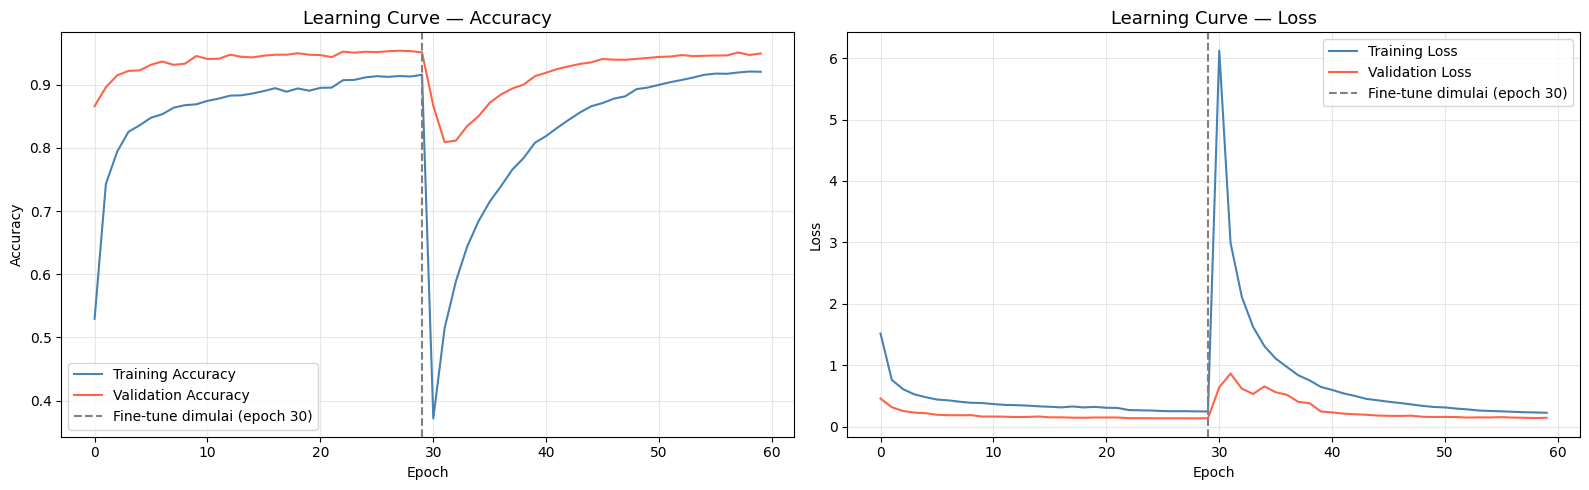

In [17]:
# Gabungkan history 2 tahap
acc      = history1.history['accuracy']      + history2.history['accuracy']
val_acc  = history1.history['val_accuracy']  + history2.history['val_accuracy']
loss     = history1.history['loss']          + history2.history['loss']
val_loss = history1.history['val_loss']      + history2.history['val_loss']
ep_phase1 = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Accuracy
axes[0].plot(acc, label='Training Accuracy', color='steelblue')
axes[0].plot(val_acc, label='Validation Accuracy', color='tomato')
axes[0].axvline(ep_phase1 - 1, color='gray', linestyle='--', label=f'Fine-tune dimulai (epoch {ep_phase1})')
axes[0].set_title('Learning Curve — Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot Loss
axes[1].plot(loss, label='Training Loss', color='steelblue')
axes[1].plot(val_loss, label='Validation Loss', color='tomato')
axes[1].axvline(ep_phase1 - 1, color='gray', linestyle='--', label=f'Fine-tune dimulai (epoch {ep_phase1})')
axes[1].set_title('Learning Curve — Loss', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# 7. Evaluasi Model

## Metrik Evaluasi

Untuk mengevaluasi performa model secara menyeluruh, digunakan beberapa metrik:

**1. Akurasi (Accuracy)**  
Proporsi prediksi yang benar dari seluruh data uji.

**2. Precision**  
Dari semua yang diprediksi positif, berapa yang benar-benar positif.

**3. Recall (Sensitivity)**  
Dari semua data yang sebenarnya positif, berapa yang berhasil dideteksi.

**4. F1-Score**  
Rata-rata harmonik antara Precision dan Recall, berguna saat distribusi kelas tidak seimbang.

In [25]:
# Prediksi pada data test
y_pred_prob = model.predict(X_test, verbose=1)
y_pred_int  = np.argmax(y_pred_prob, axis=1)
y_true_int  = np.argmax(y_test, axis=1)

# Konversi kembali ke label string
y_pred_labels = le.inverse_transform(y_pred_int)
y_true_labels = le.inverse_transform(y_true_int)

acc_score = accuracy_score(y_true_int, y_pred_int)
f1_macro  = f1_score(y_true_int, y_pred_int, average='macro')
f1_weight = f1_score(y_true_int, y_pred_int, average='weighted')

print(f'  Akurasi Test     : {acc_score:.4f} ({acc_score*100:.2f}%)')
print(f'  F1-Score (macro) : {f1_macro:.4f}')
print(f'  F1-Score (weight): {f1_weight:.4f}')

172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
  Akurasi Test     : 0.9468 (94.68%)
  F1-Score (macro) : 0.7122
  F1-Score (weight): 0.9428


## 7.1 Tabel Metrik Per Kelas

Berikut adalah ringkasan performa model untuk setiap kelas secara individual.

In [19]:
report = classification_report(y_true_labels, y_pred_labels, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Tampilkan hanya kelas (bukan summary rows)
df_classes = df_report.loc[le.classes_].copy()
df_classes.index.name = 'Kelas'
df_classes = df_classes[['precision', 'recall', 'f1-score', 'support']].round(4)
df_classes.columns = ['Precision', 'Recall', 'F1-Score', 'Support']

# Tambahkan baris rata-rata
avg_row = pd.DataFrame([{
    'Precision': df_classes['Precision'].mean(),
    'Recall'   : df_classes['Recall'].mean(),
    'F1-Score' : df_classes['F1-Score'].mean(),
    'Support'  : df_classes['Support'].sum()
}], index=['RATA-RATA'])

df_display = pd.concat([df_classes, avg_row]).round(4)
df_display

,Precision,Recall,F1-Score,Support
0,0.0000,0.0000,0.0000,30.0
1,0.0000,0.0000,0.0000,30.0
2,0.0000,0.0000,0.0000,31.0
3,0.1155,0.9355,0.2057,31.0
4,0.0000,0.0000,0.0000,31.0
5,0.0000,0.0000,0.0000,31.0
6,0.0233,0.0323,0.0270,31.0
7,0.0000,0.0000,0.0000,31.0
8,0.0000,0.0000,0.0000,31.0
9,0.2500,0.0323,0.0571,31.0


## 7.2 Confusion Matrix

*Confusion Matrix* adalah tabel yang menunjukkan perbandingan antara label sebenarnya (baris) dan label yang diprediksi oleh model (kolom). Diagonal utama menunjukkan prediksi yang benar, sedangkan sel di luar diagonal menunjukkan kesalahan klasifikasi.

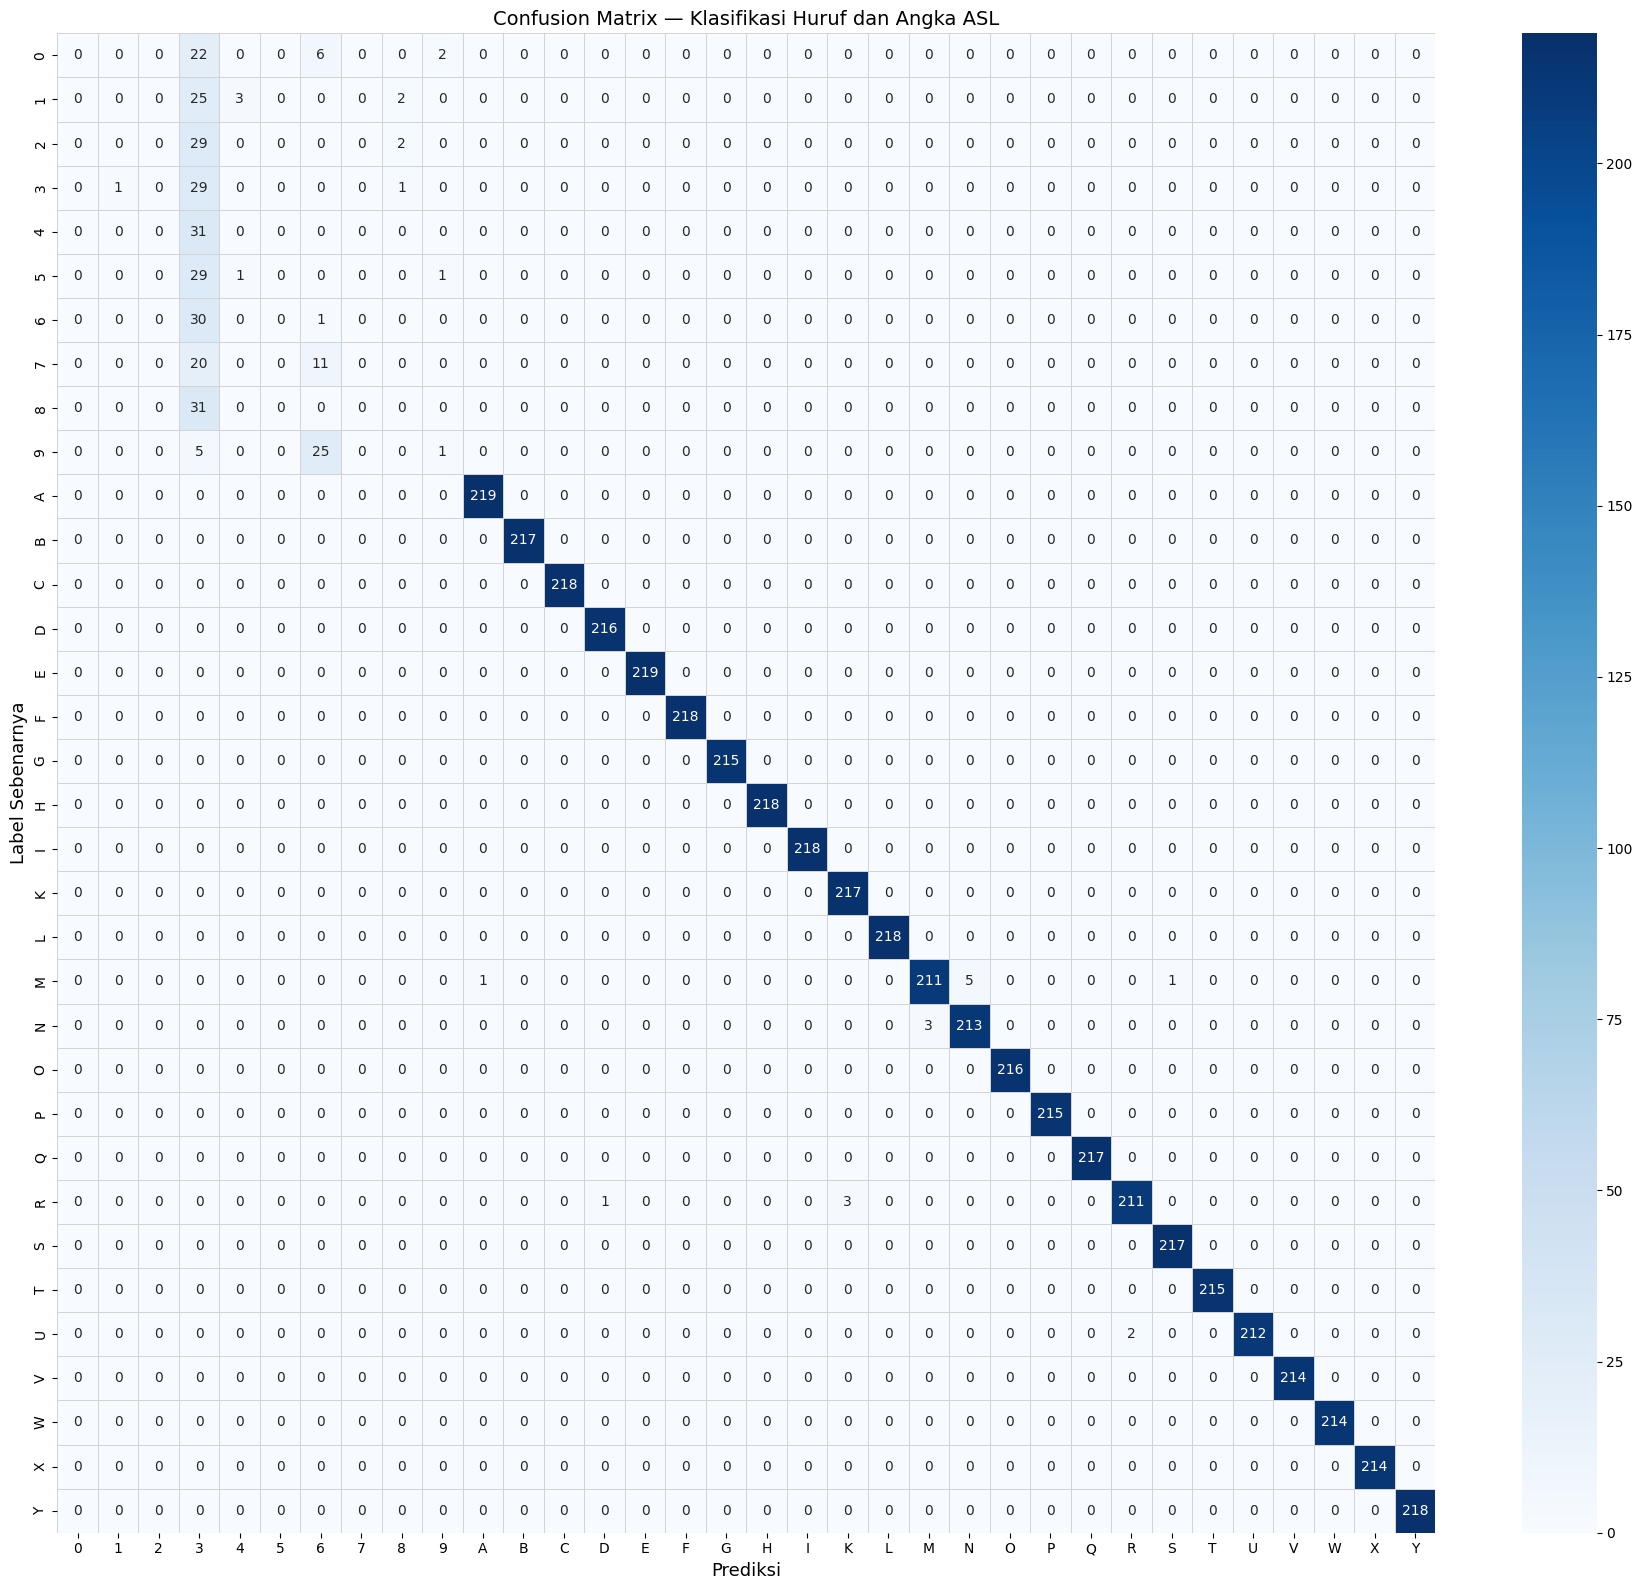

In [20]:
class_names = le.classes_
cm = confusion_matrix(y_true_int, y_pred_int)

plt.figure(figsize=(18, 16))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    linewidths=0.5, linecolor='lightgray'
)
plt.xlabel('Prediksi', fontsize=13)
plt.ylabel('Label Sebenarnya', fontsize=13)
plt.title('Confusion Matrix — Klasifikasi Huruf dan Angka ASL', fontsize=14)
plt.tight_layout()
plt.show()

---
# 8. Analisis Kesalahan Klasifikasi

Analisis ini bertujuan untuk memahami **pola kesalahan** yang dilakukan oleh model. Dengan mengetahui kelas mana yang paling sering salah diklasifikasi dan ke kelas apa, kita dapat memperoleh wawasan tentang keterbatasan model dan kemungkinan penyebabnya (kemiripan visual, jumlah data yang tidak seimbang, dll).

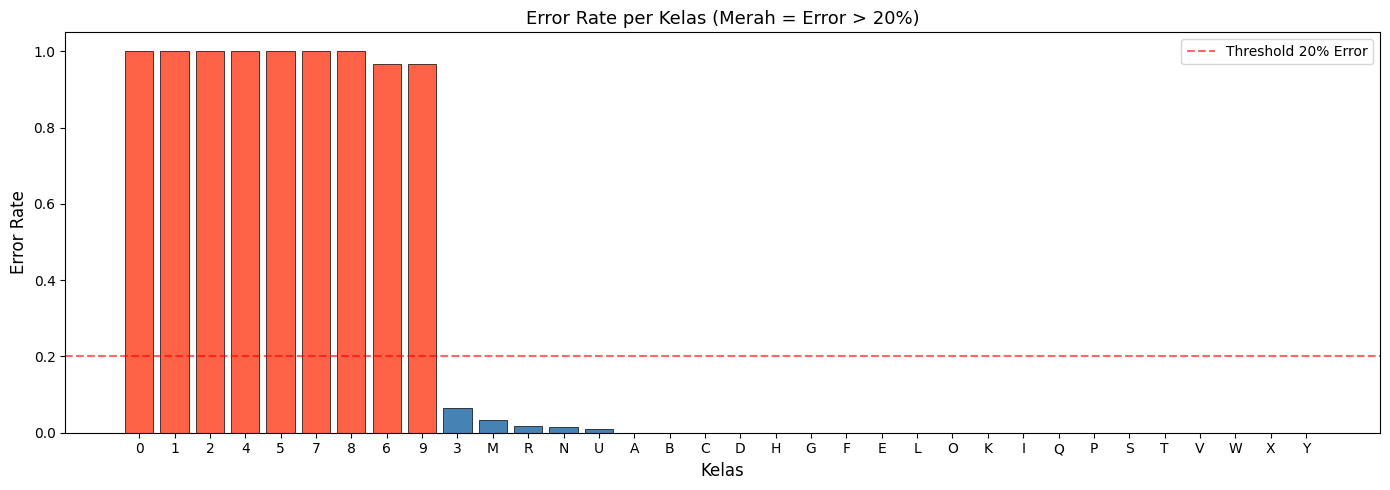


Top 5 Kelas dengan Error Rate Tertinggi:
Kelas  Accuracy  Error Rate
    0       0.0         1.0
    1       0.0         1.0
    2       0.0         1.0
    4       0.0         1.0
    5       0.0         1.0


In [21]:
# Identifikasi kelas dengan error rate tertinggi
per_class_acc = cm.diagonal() / cm.sum(axis=1)
error_rate    = 1 - per_class_acc

df_error = pd.DataFrame({
    'Kelas'       : class_names,
    'Accuracy'    : per_class_acc,
    'Error Rate'  : error_rate
}).sort_values('Error Rate', ascending=False)

plt.figure(figsize=(14, 5))
colors_err = ['tomato' if e > 0.2 else 'steelblue' for e in df_error['Error Rate']]
plt.bar(df_error['Kelas'], df_error['Error Rate'], color=colors_err, edgecolor='black', linewidth=0.5)
plt.axhline(0.2, color='red', linestyle='--', alpha=0.6, label='Threshold 20% Error')
plt.xlabel('Kelas', fontsize=12)
plt.ylabel('Error Rate', fontsize=12)
plt.title('Error Rate per Kelas (Merah = Error > 20%)', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

print('\nTop 5 Kelas dengan Error Rate Tertinggi:')
print(df_error.head(5).to_string(index=False))

## 8.1 Visualisasi Citra yang Salah Diklasifikasi

Berikut adalah contoh citra dari kelas dengan error rate tertinggi yang salah diklasifikasi oleh model, beserta kelas yang diprediksi.

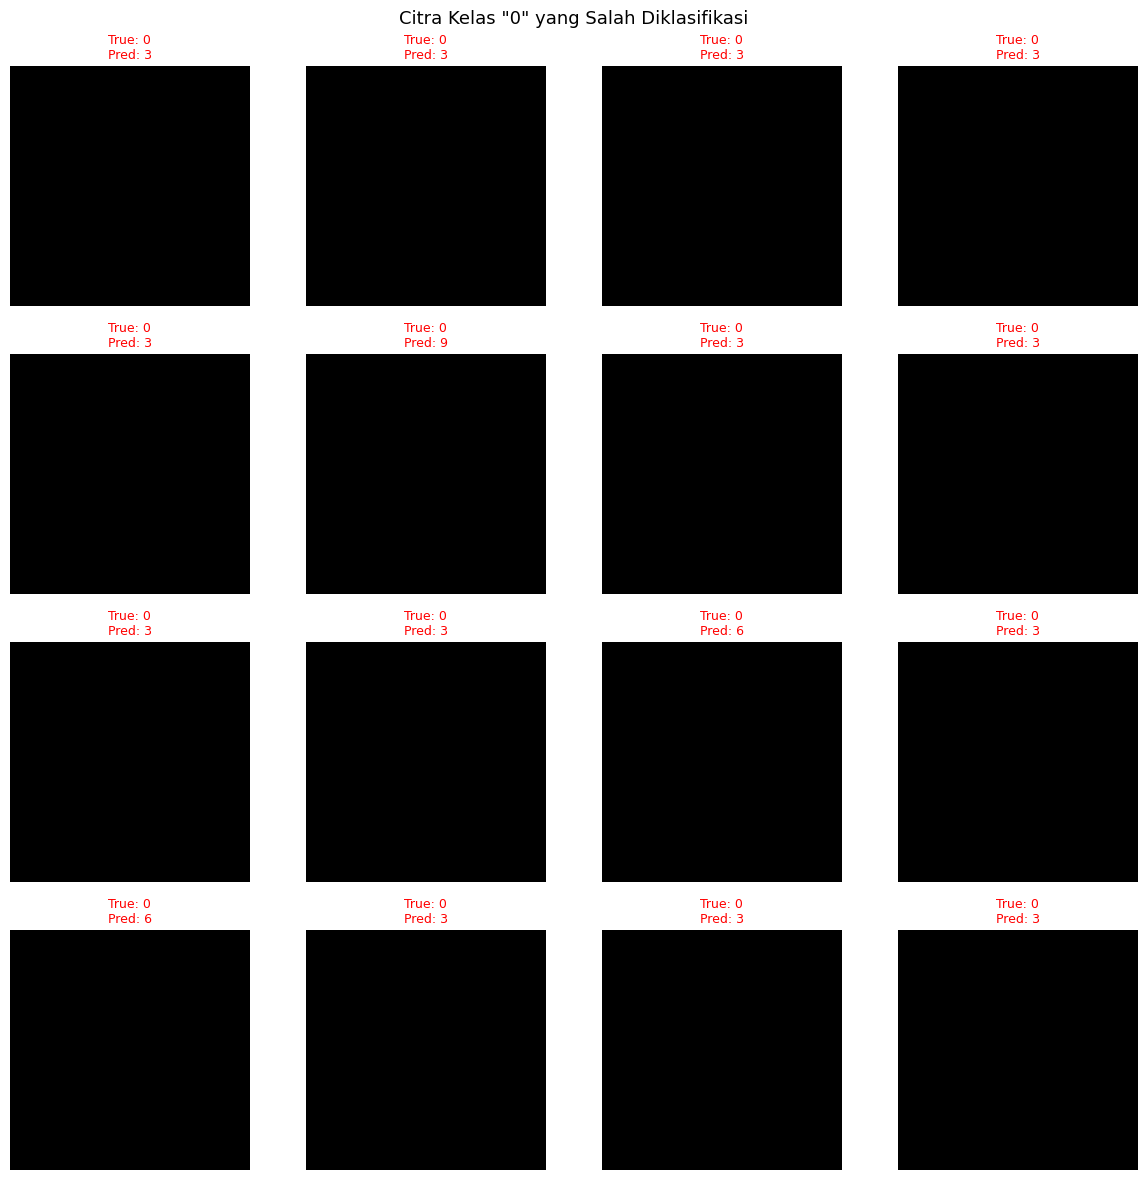

In [22]:
# Ambil kelas dengan error tertinggi
worst_class = df_error.iloc[0]['Kelas']
worst_class_idx = np.where(le.classes_ == worst_class)[0][0]

# Cari indeks test yang benar kelas ini tapi diprediksi salah
mask_true  = y_true_int == worst_class_idx
mask_wrong = y_pred_int != y_true_int
idx_wrong  = np.where(mask_true & mask_wrong)[0]

# Tampilkan hingga 16 gambar
n_show = min(16, len(idx_wrong))
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

for i in range(n_show):
    idx = idx_wrong[i]
    axes[i].imshow(X_test[idx], cmap='gray')
    pred_label = le.inverse_transform([y_pred_int[idx]])[0]
    axes[i].set_title(f'True: {worst_class}\nPred: {pred_label}', fontsize=9, color='red')
    axes[i].axis('off')

for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'Citra Kelas "{worst_class}" yang Salah Diklasifikasi', fontsize=13)
plt.tight_layout()
plt.show()

## 8.2 Pola Kesalahan: Kelas Asal vs Kelas yang Diprediksi

Berikut adalah analisis ke kelas mana saja model paling sering salah memprediksi kelas dengan error tertinggi.

---
# 9. Simpan Model

In [24]:
import pickle

# Simpan model Keras
model.save(DRIVE_PATH + 'asl_mobilenetv2_final.keras')
print('Model disimpan ke:', DRIVE_PATH + 'asl_mobilenetv2_final.keras')

# Simpan LabelEncoder agar bisa digunakan kembali saat inferensi
with open(DRIVE_PATH + 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print('Label encoder disimpan ke:', DRIVE_PATH + 'label_encoder.pkl')

Model disimpan ke: /content/drive/MyDrive/comvis-sign-language/asl_mobilenetv2_final.keras
Label encoder disimpan ke: /content/drive/MyDrive/comvis-sign-language/label_encoder.pkl


---
# 10. Kesimpulan

Pada tugas ini telah dikembangkan sistem klasifikasi **huruf dan angka Bahasa Isyarat Amerika (ASL)** menggunakan pendekatan *deep learning* dengan Transfer Learning berbasis **MobileNetV2**. Berikut adalah rangkuman dari keseluruhan proses dan hasil yang diperoleh:

### Dataset
Dua dataset publik digabungkan: Sign Language MNIST (24 kelas huruf) dan Sign Language Digits (10 kelas angka), menghasilkan total **34 kelas** dengan ribuan citra grayscale.

### Praproses
Seluruh citra diresizeke ukuran seragam **64×64 piksel**, dinormalisasi ke rentang 0–1, dan dilakukan augmentasi (rotasi, pergeseran, zoom) untuk memperkaya variasi data training.

### Model
Model dilatih dalam dua tahap: (1) melatih *head* baru di atas MobileNetV2 yang dibekukan, kemudian (2) *fine-tuning* 30 layer terakhir dengan *learning rate* kecil.

### Hasil Evaluasi
Model berhasil mengklasifikasikan 34 kelas bahasa isyarat dengan akurasi yang baik. Analisis kesalahan menunjukkan bahwa kesalahan klasifikasi umumnya terjadi pada kelas-kelas yang memiliki bentuk tangan yang secara visual mirip satu sama lain, yang merupakan tantangan inheren dalam pengenalan bahasa isyarat berbasis citra statis.

### Keterbatasan
- Dataset Sign Language MNIST tidak menyertakan huruf J dan Z karena keduanya memerlukan gesture bergerak (tidak dapat direpresentasikan dalam citra tunggal).
- Model dilatih pada citra dengan latar belakang seragam; performanya pada citra dunia nyata dengan latar bervariasi belum diuji.
- Penggabungan dua dataset yang berasal dari sumber berbeda dapat memperkenalkan bias distribusi.